In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
import os
from os import listdir
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image
from keras.utils import img_to_array, array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dropout, Dense
from sklearn. model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical

In [18]:
print(tf.__version__)

2.16.1


In [19]:
dataset_path = "C:\Brain Stroke image dataset\Brain_Data_Organised"

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_17412\2086169243.py:1: SyntaxWarning: invalid escape sequence '\B'
  dataset_path = "C:\Brain Stroke image dataset\Brain_Data_Organised"


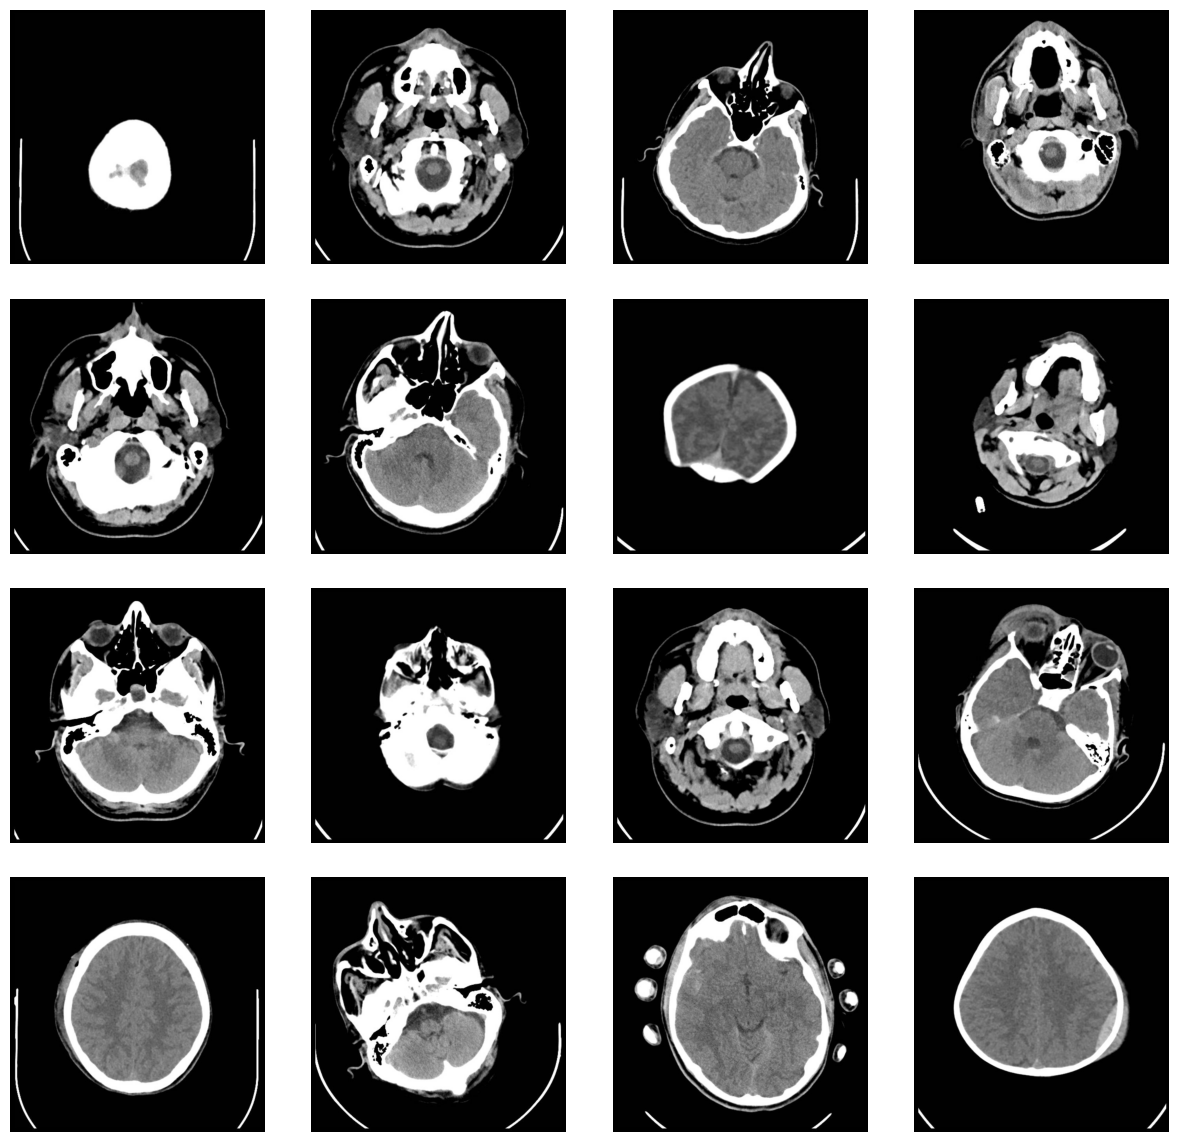

In [20]:
Stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"

plt.figure(figsize=(12, 12))
for i in range(1, 17):
    plt.subplot(4, 4, i)
    plt.tight_layout()
    rand_img_path = os.path.join(Stroke_path, random.choice(sorted(os.listdir(Stroke_path))))
    rand_img = cv2.imread(rand_img_path)
    rand_img = cv2.cvtColor(rand_img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    plt.imshow(rand_img)
    plt.axis("off")
plt.show()


In [21]:
def convert_image_to_array(image_dir):
    try:
        image = cv2.imread(image_dir)
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            image = cv2.resize(image, (128, 128))
            return img_to_array(image)
        else:
            return np.array([])
    except Exception as e:
        print(f"Error: {e}")
        return None


In [22]:
dataset_path =  "C:\Brain Stroke image dataset\Brain_Data_Organised"
labels = os.listdir(dataset_path)

print(labels)


['Normal', 'Stroke']


<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_17412\683414539.py:1: SyntaxWarning: invalid escape sequence '\B'
  dataset_path =  "C:\Brain Stroke image dataset\Brain_Data_Organised"


In [23]:
image_list, label_list = [], []
all_labels = ['Normal', 'Stroke']
binary_labels = [0, 1]

for index, directory in enumerate(all_labels):  
    brain_image_list = os.listdir(os.path.join(dataset_path, directory))
    for file in brain_image_list:
        image_path = os.path.join(dataset_path, directory, file)
        image_list.append(convert_image_to_array(image_path))
        label_list.append(binary_labels[index])


In [24]:
# Visualize the number of classes count

label_counts = pd.DataFrame(label_list).value_counts()
label_counts.head()

0    1551
1     950
Name: count, dtype: int64

In [25]:
image_list[0].shape

(128, 128, 3)

In [26]:
label_list = np.array(label_list)
label_list.shape

(2501,)

In [27]:
label_list = np.array(label_list)
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state=10) 

x_train = np.array(x_train, dtype=np.float16) / 255.0
x_test = np.array(x_test, dtype=np.float16) / 255.0
x_train = x_train.reshape(-1, 128, 128, 3)
x_test = x_test.reshape(-1, 128, 128, 3)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [28]:
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  
])
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
model.summary()

c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,926,786 (129.42 MB)

 Trainable params: 33,926,786 (129.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    "C:/Brain Stroke image dataset/Brain_Data_Organised",  
    target_size=(128, 128),
    batch_size=32,  
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    "C:/Brain Stroke image dataset/Brain_Data_Organised",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

history = model.fit(train_generator, validation_data=val_generator, epochs=50)


Found 2001 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/50


c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.6244 - loss: 0.6561 - val_accuracy: 0.6080 - val_loss: 0.6298
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 994ms/step - accuracy: 0.7108 - loss: 0.5306 - val_accuracy: 0.6260 - val_loss: 0.7271
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8516 - loss: 0.3479 - val_accuracy: 0.6400 - val_loss: 0.7143
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9378 - loss: 0.1949 - val_accuracy: 0.6260 - val_loss: 0.9150
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 985ms/step - accuracy: 0.9658 - loss: 0.1131 - val_accuracy: 0.6660 - val_loss: 1.1352
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9856 - loss: 0.0599 - val_accuracy: 0.6480 - val_loss: 1.5366
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9856 - loss: 0.0518 - val_accuracy: 0.6120 - val_loss: 1.3309
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9939 - loss: 0.0278 - val_accuracy: 0.6760 - val_loss: 1.65

In [30]:
scores = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1] * 100:.2f}%")


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.9396 - loss: 0.6839
Test Accuracy: 92.42%


In [31]:
loss, acc = model.evaluate(x_test,y_test)
print("Loss on Test Data:",loss)
print("Accuracy on Test Data:",acc)

loss, acc = model.evaluate(x_train,y_train)
print("Loss on Train Data:",loss)
print("Accuracy on Train Data:",acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.9396 - loss: 0.6839
Loss on Test Data: 0.7550017833709717
Accuracy on Test Data: 0.9241517186164856
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9408 - loss: 0.6054
Loss on Train Data: 0.6673479080200195
Accuracy on Train Data: 0.9334999918937683


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.9396 - loss: 0.6839
✅ Test Accuracy: 92.42%
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step

📊 Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.96      0.94       303
      Stroke       0.94      0.86      0.90       198

    accuracy                           0.92       501
   macro avg       0.93      0.91      0.92       501
weighted avg       0.92      0.92      0.92       501



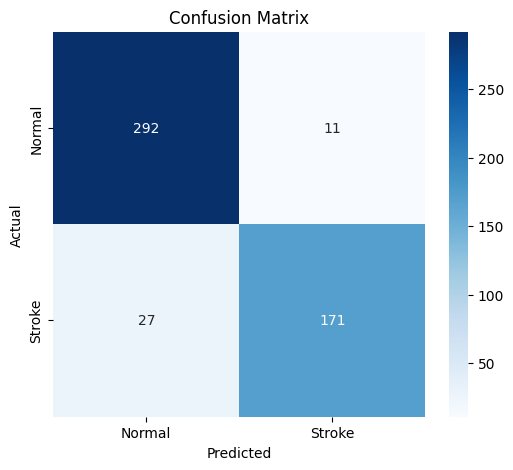

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

categories = ["Normal", "Stroke"]  


# Evaluate model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=["Normal", "Stroke"]))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [34]:
model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\model.h5")


<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_17412\2252487159.py:1: SyntaxWarning: invalid escape sequence '\B'
  model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\model.h5")


In [42]:
print("Actual Label:",y_test[:10])
print("Predicted Label:",y_pred_classes[:10])

Actual Label: [[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
Predicted Label: [0 0 0 1 1 0 0 0 1 1]


In [36]:
y_pred_labels = np.argmax(y_pred, axis=1)  # Converts probabilities to class labels


In [43]:
y_test_labels = np.argmax(y_test, axis=1)
print(y_pred_classes)  # Should match y_test_labels if predictions are correct


[0 0 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1
 0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0
 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1
 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1
 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0
 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0
 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0 0
 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1
 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0
 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 1 

In [ ]:
history.history #Return Dictionary of history

In [19]:
import json
with open('training_hist.json','w') as f:
  json.dump(history.history,f)
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [20]:
history.history['accuracy']

[0.6268749833106995,
 0.6631249785423279,
 0.7281249761581421,
 0.7524999976158142,
 0.8043749928474426,
 0.8274999856948853,
 0.8512499928474426,
 0.8631250262260437,
 0.8856250047683716,
 0.8812500238418579,
 0.9006249904632568,
 0.9137499928474426,
 0.9256250262260437,
 0.9318749904632568,
 0.9449999928474426,
 0.9418749809265137,
 0.9574999809265137,
 0.9593750238418579,
 0.9662500023841858,
 0.9700000286102295,
 0.9725000262260437,
 0.9674999713897705,
 0.9737499952316284,
 0.9768750071525574,
 0.9787499904632568,
 0.9831249713897705,
 0.9806249737739563,
 0.9856250286102295,
 0.984375,
 0.9868749976158142,
 0.9881250262260437,
 0.9906250238418579,
 0.9918749928474426,
 0.9925000071525574,
 0.9925000071525574,
 0.9931250214576721,
 0.9943749904632568,
 0.9931250214576721,
 0.996874988079071,
 0.9956250190734863,
 0.9925000071525574,
 0.9943749904632568,
 0.996874988079071,
 0.996874988079071,
 0.9975000023841858,
 0.9981250166893005,
 0.9975000023841858,
 0.9987499713897705,
 0.99

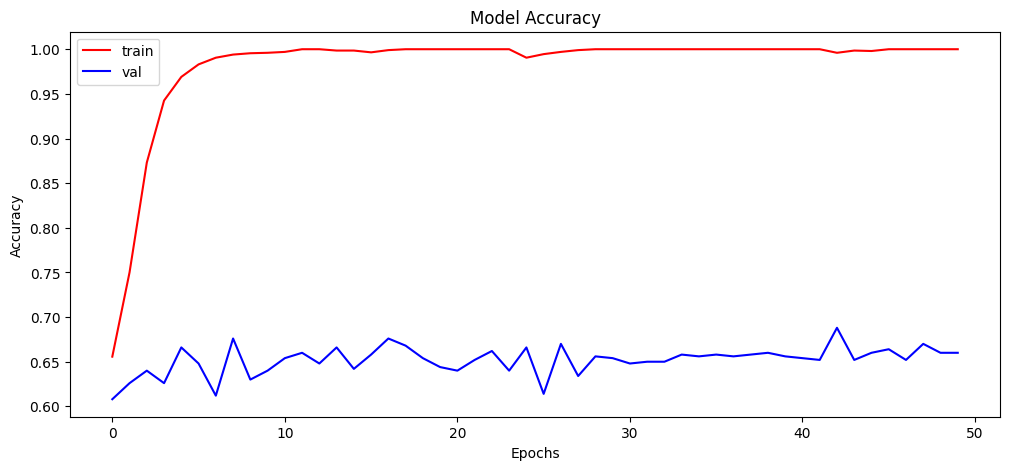

In [47]:
plt.figure(figsize = (12, 5))
plt.plot(history.history['accuracy'], color = 'r')
plt.plot(history.history['val_accuracy'], color = 'b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

In [48]:
print("Calculating model accuracy")

scores = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1] * 100}")

Calculating model accuracy
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.9396 - loss: 0.6839
Test Accuracy: 92.41517186164856


Actual Label: Stroke
Predicted Label: Stroke


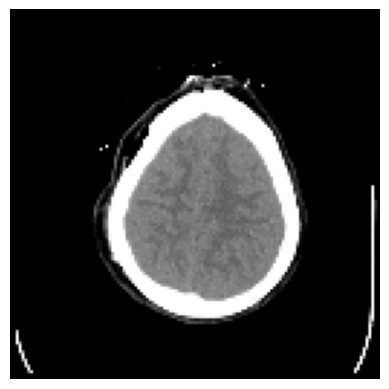

✅ Image saved as: test_images/test_image_3_Stroke.png
📌 Image Class: Stroke
📏 Image Dimensions: 128x128, Channels: 3


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array

# Define class labels
class_labels = ["Normal", "Stroke"]

# Class labels (Modify based on your dataset)
class_labels = ["Normal", "Stroke"]

# Select an index for testing
index = 3 # Change this to test different images

# Convert the image array to an actual image (optional)
img = array_to_img(x_test[index])  

# Get the actual label (Convert one-hot to integer)
actual_label = class_labels[np.argmax(y_test[index])]

# Get the predicted label
predicted_label = class_labels[np.argmax(y_pred[index])]

# Print the labels
print(f"Actual Label: {actual_label}")
print(f"Predicted Label: {predicted_label}")


# Get image dimensions
img_array = img_to_array(img)  # Convert back to array
height, width, channels = img_array.shape

# Display the image with class label and dimensions
plt.imshow(img, cmap="gray")
plt.axis('off')  # Remove axis
plt.show()

# Save the image with class name in filename
output_dir = 'test_images'  # Define directory
if not os.path.exists(output_dir):
    os.makedirs(output_dir)  # Create if it doesn't exist

# Save with class name in filename
img_filename = f"{output_dir}/test_image_{index}_{actual_label}.png"
img.save(img_filename)

# Print image details
print(f"✅ Image saved as: {img_filename}")
print(f"📌 Image Class: {actual_label}")
print(f"📏 Image Dimensions: {width}x{height}, Channels: {channels}")


In [56]:
# Loop through the first 50 test samples
for i in range(50):
    actual_label = all_labels[np.argmax(y_test[i])]  # Get actual class
    predicted_label = all_labels[np.argmax(y_pred[i])]  # Get predicted class
    
    print(f"Sample {i+1}: Actual = {actual_label}, Predicted = {predicted_label}")


Sample 1: Actual = Normal, Predicted = Normal
Sample 2: Actual = Normal, Predicted = Normal
Sample 3: Actual = Normal, Predicted = Normal
Sample 4: Actual = Stroke, Predicted = Stroke
Sample 5: Actual = Stroke, Predicted = Stroke
Sample 6: Actual = Normal, Predicted = Normal
Sample 7: Actual = Normal, Predicted = Normal
Sample 8: Actual = Normal, Predicted = Normal
Sample 9: Actual = Stroke, Predicted = Stroke
Sample 10: Actual = Stroke, Predicted = Stroke
Sample 11: Actual = Stroke, Predicted = Normal
Sample 12: Actual = Normal, Predicted = Normal
Sample 13: Actual = Normal, Predicted = Normal
Sample 14: Actual = Stroke, Predicted = Stroke
Sample 15: Actual = Stroke, Predicted = Stroke
Sample 16: Actual = Normal, Predicted = Normal
Sample 17: Actual = Stroke, Predicted = Normal
Sample 18: Actual = Normal, Predicted = Normal
Sample 19: Actual = Normal, Predicted = Normal
Sample 20: Actual = Normal, Predicted = Normal
Sample 21: Actual = Normal, Predicted = Normal
Sample 22: Actual = St